#Harman Hothi  (917604942)

# ECI 115: Homework 5

## <font color='red'>**Problem 8.18**</font>

The concentration of pollutant bacteria $c$ in a lake decreases according to

$c=75e^{-1.5t}+20e^{-0.075t}$

Determine the time required for the bacteria concentration to be reduced to 9 using (a) the graphical method and (b) the Newton-Raphson method with an initial guess of $t=$ 6 and a stoppping criterion of 0.5%. Check your result.

<font color='red'> **TL;DR**:
Explain how the the Newton-Raphson method works and how it can be applied to solving this problem. Create programs to compute when $c(t)=9$ using (a) the graphical method and (b) the Newton-Raphson method (be sure to print the value for $t$, the number of iterations, and the approximate error). Discuss the rate/accuracy of your methods and the physical significance of this root.
</font>

### <font color='blue'>**Solution 8.18**</font>

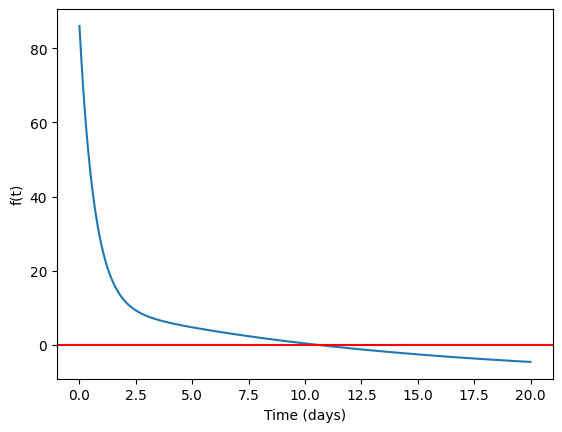

Estimate of root: 10.6468
Iterations: 3


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(t):
  return 75*np.exp(-1.5*t) + 20*np.exp(-0.075*t) - 9

# (a) Graphical method
t = np.arange(0,20,0.01)
plt.plot(t, f(t))
plt.axhline(0, color='red')
plt.xlabel('Time (days)')
plt.ylabel('f(t)')
plt.show()

# (b) Newton-Raphson Method

def fp(t):
  return -112.5*np.exp(-1.5*t) - 1.5*np.exp(-0.075*t)

# lecture example code
def newtonraphson(f, fp, x, tol=1e-8):

  err = 9999
  errors = [] # store errors to plot later

  while err > tol:
    x = x-f(x)/fp(x)
    err = np.abs(f(x))
    errors.append(err)

  return x, errors

xr, errors = newtonraphson(f, fp, 6, tol=0.005)

print('Estimate of root: %0.4f' % xr)
print('Iterations: %d' % len(errors))


**Discussion of Results**

[The Newton–Raphson method works by starting with a guess for the root and then using the slope of the function to quickly improve that guess using the formula tnew = t - f(t)/f'(t). Each iteration uses the tangent line at the current point to move closer to where the function crosses zero, which makes the method fast and accurate when the derivative is correct. In this problem, we apply Newton–Raphson to the equation f(t) = 75e^-1.5t + 20e^-0.075t -9 to find when the pollutant concentration in the lake drops to 9. Starting from t =6, the method converges in just a few steps to about t = 10.65 days, which is much more precise than the graphical estimate.

The graphical method provides only a rough estimate of the time at which the bacteria concentration reaches 9, since it depends on visually identifying where the curve f(t) = 75e^-1.5t + 20e^-0.075t - 9 crosses zero.  What this does is give an approximate value near t = 10.6 days but with limited precision. In contrast, the Newton–Raphson method is much more accurate and converges very quickly.  What it does is start at t = 6 and it reaches the root near t=10.65 days in only a few iterations because the error drops sharply each step. This root represents the time when the bacteria concentration in the lake decreases to 9, meaning it is the point when the pollution level has fallen to the desired safe or acceptable threshold. ]

## <font color='red'>**Problem 8.21**</font>

The displacement of a structure is defined by the following equation for a damped oscillation:

$$y=9e^{-kt}cos\ \omega t$$

where $k=0.7$ and $\omega = 4$.

(a) Use the graphical method to make an initial estimate of the time required for the displacement to decrease to 4.

(b) Use the Newton-Raphson method to determine the root to $\varepsilon_s=0.01\%$.

(c) Use the secant method to determine the root to $\varepsilon_s=0.01\%$.

<font color='red'> **TL;DR**:
Explain how the the Newton-Raphson and Secant methods works and how it can be applied to solving this problem. Create programs to determine the root using (a) the graphical method, (b) the Newton-Raphson method, and (c) the secant method. Have these programs print the value for $y$, $t$, the number of iterations, and the approximate error. Discuss the rate/accuracy of your methods and the physical significance of this root.
</font>

### <font color='blue'>**Solution 8.21**</font>

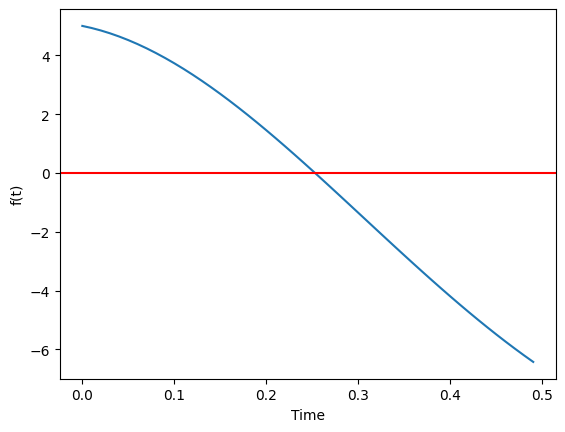

Estimate of root: 0.2529
Iterations: 2
Estimate of root: 0.2529
Iterations: 3


In [7]:
import numpy as np
import matplotlib.pyplot as plt

def f(t):
  return 9*np.exp(-0.7*t)*np.cos(4*t) - 4

# (a) Graphical method
t = np.arange(0,0.5,0.01)
plt.plot(t, f(t))
plt.axhline(0, color='red')
plt.xlabel('Time')
plt.ylabel('f(t)')
plt.show()

# (b) Newton-Raphson (use any initial guess)

def fp(t):
  return -36*np.exp(-0.7*t)*np.sin(4*t) - 6.3*np.exp(-0.7*t)*np.cos(4*t)

# lecture example code
def newtonraphson(f, fp, x, tol=1e-8):

  err = 9999
  errors = [] # store errors to plot later

  while err > tol:
    x = x-f(x)/fp(x)
    err = np.abs(f(x))
    errors.append(err)

  return x, errors

xr, errors = newtonraphson(f, fp, 0.25, tol=0.0001)

print('Estimate of root: %0.4f' % xr)
print('Iterations: %d' % len(errors))

# (c) Secant method (any initial guess)
def secant(f, x0, tol=1e-6):
  err = 9999
  errors = [] #store errors to plot later

  x1=x0 + 0.01

  while err > tol:
    temp = x1
    x1 = x1 - f(x1) * (x0 - x1) / (f(x0) - f(x1))
    x0 = temp
    err = np.abs(f(x1))
    errors.append(err)

  return x1, errors

xr, errors = secant(f, 0.3, tol=0.0001)

print('Estimate of root: %0.4f' % xr)
print('Iterations: %d' % len(errors))


**Discussion of Results**

[The Newton-Raphson and Secant methods are numerical ways to find where a function crosses zero.  Newton-Raphson uses the function's slope to quickly update an initial guess, while the Secant method estimates the slope using two nearby points, so it does not need the derivative. In this problem, both methods are used to solve f(t) = 9e^-0.7 cos(4t)-4 = 0, which tells us when the damped oscillation reaches a displacement of 4.  By repeatedly updating the guesses, each method narrows in on the correct value of t.

Newton-Raphson converged in 2 iterations, while the Secant method took 3, showing that Newton-Raphson is faster and a bit more accurate for this function.  The root they find which is t = 0.2529 represents the exact time when the structure’s displacement falls to 4. This is important physically because it identifies when the oscillation reaches this specific level, which can help engineers understand how the system behaves and when it crosses key thresholds.
]

## <font color='red'>**Problem 16.17**</font>

A finite-element model of a cantilever beam subject to loading and moments (Fig. P16.17) is given by optimizing

$$f(x,y)=5x^2-5xy+2.5y^2-x-1.5y$$

<p align="center">
  <img src="https://github.com/cdefinnda/ECI-115_HW-Images/blob/main/HW5_Fig.P16.17.png?raw=true" alt="Fig. P16.17" width=500>
</p>

where $x=$ end displacement and $y=$ end moment. Find the values of $x$ and $y$ that minimize $f(x,y)$.

<font color='red'> **TL;DR**:
Explain how to set up this optimization problem to determine the point of minimal stress on the cantilever. Create programs that identifies the $x$ and $y$ values where the stress on the cantilever beam ($f(x,y)$) are at a minimum. No optimization method is specificed, so try using the `minimize` function in the `scipy.optimize` package. Print out the optimal values for displacement ($x$), moment ($y$), and stress ($f(x,y)$). Discuss the physical significance of this optimization.
</font>

### <font color='blue'>**Solution 16.17**</font>



In [8]:
# input vector x: x[0]=x and x[1]=y
def f(x):
  return 5*x[0]**2 - 5*x[0]*x[1] + 2.5*x[1]**2 - x[0] - 1.5*x[1]

from scipy.optimize import minimize
res = minimize(f, x0=[1,1])
# or use gradient ascent / Newton's method
# for Newton's method you would also have to calculate the gradient and Hessian for
# it is also ok to solve analytically for the optim

print(res)



  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.849999999999999
        x: [ 5.000e-01  8.000e-01]
      nit: 2
      jac: [ 0.000e+00  1.043e-07]
 hess_inv: [[ 3.273e-01  4.198e-01]
            [ 4.198e-01  7.797e-01]]
     nfev: 15
     njev: 5


**Discussion of Results**

[To set up this optimization problem, we treat the stress function of f(x,y) = 5x^2 - 5xy + 2.5y^2 - x -1.5y as  something we want to minimize.  The variables x and y represent the beam's end displacement and end moment, and the goal is to find the values of x and y that make the stress as small as possible. In the code, this is done by defining f(x) using minimize with an initial guess. What this does is searches for the point where the function reaches its lowest value.  

The physical significance of this optimization is that the minimum of f(x,y) tells us the condition where the beam experiences the least amount of stress. This is important because it shows how the cantilever naturally settles under the applied loading and which combination of displacement and moment leads to the safest, least-stressed state.  Finding this point helps engineers understand how the beam behaves and whether the structure stays within safe stress levels.
]

## <font color='red'>**Problem 16.19**</font>

The *Streeter-Phelps model* can be used to compute the dissolved oxygen concentraiton in a river below a point discharge of sewage (Fig. P16.19),

$o=o_s-\frac{k_d L_0}{k_d+k_s-k_a}(e^{-k_at}-e^{-(k_d+k_s)t})-\frac{S_b}{k_a}(1-e^{-k_a t}) \tag{P16.19}$

where $o=$ dissolved oxygen concentration (mg/L), $o_s=$ oxygen saturation concentraiton (mg/L), $t=$ travel time (d), $L_0=$ biochemical oxygen demand (BOD) concentration at the mixing point (mg/L), $k_d=$ rate of decomposition of BOD (d$^{-1}$), $k_s=$ rate of settling of BOD (d$^{-1}$), $k_a=$ re-aeration rate (d$^{-1}$), and $S_b=$ sedimentation oxygen demand (mg/L/d). As indicated in Fig. P16.19, Eq. (P16.19) describes an oxygen "sag" that reaches a critical minimum level $o_c$ some travel time $t_c$ below the point discharge. This point is called "critical" because it represents the location where biota that depend on oxygen (like fish) would be the most stressed. Determine the critical travel time and concentration, given the following values:

$o_s=$ 10 mg/L; $\ \ \ k_d =$ 0.2 d$^{-1}$; $\ \ \ k_a =$ 0.8 d$^{-1}$;

$k_s =$ 0.06 d$^{-1}$; $\ \ \ L_0 =$ 50 mg/L; $\ \ \ S_b =$ 1 mg/L/d;

<p align="center">
  <img src="https://github.com/cdefinnda/ECI-115_HW-Images/blob/main/HW5_Fig.P16.19.png?raw=true" alt="Fig. P16.17" width=500>
</p>

<font color='red'> **TL;DR**:
Explain how to set up this optimization problem to determine $t_c$. Create programs that identifies $t_c$ and the corresponding value for $o$. No optimization method is specificed, so you can use the `minimize` function in the `scipy.optimize` package. Print out the values for the critical travel time ($t_c$) and critical oxygen concentration ($o_c$). Discuss the physical significance of this optimization.
</font>

### <font color='blue'>**Solution 16.19**</font>



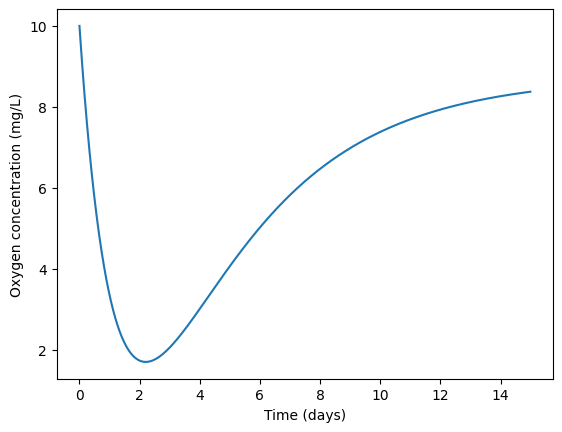

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.699299292864716
        x: [ 2.202e+00]
      nit: 4
      jac: [ 9.969e-06]
 hess_inv: [[ 6.864e-01]]
     nfev: 10
     njev: 5


In [13]:
os = 10
kd = 0.2
ka = 0.8
ks = 0.06
Lo = 50
Sb = 1
def f(t):
  return os - (kd*Lo) / (kd + ks - ka) * (np.exp(-ka*t) - np.exp(-(kd+ks)*t)) \
          - (Sb/ka) * (1-np.exp(-ka*t))
t = np.arange(0,15,0.01)
plt.plot(t,f(t))
plt.xlabel('Time (days)')
plt.ylabel('Oxygen concentration (mg/L)')
plt.show()

res = minimize(f, x0=2)
print(res)


**Discussion of Results**

[To find the critical travel time tc, we treat the dissolved oxygen equation o(t) as a function that depends only on time. The critical point occurs where the oxygen level reaches its minimum, so the problem becomes where we find the value of t that makes o(t) as small as possible.  In the code, we define this function as f(t) and then use an optimization routine (minimize) with an initial guess for t.  The optimizer searches for the time where the function reaches its lowest point, which gives us tc.

This optimization is important because the minimum of o(t) represents the point downstream where the river has the lowest oxygen level, which is when aquatic life is under the most stress. Finding tc tells us how long after the sewage discharge the river reaches its worst water quality, helping engineers know where problems are likely to occur and whether more treatment or aeration is needed.
]